In [3]:
# --- 1. Mount Google Drive & Import Libraries ---
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# --- 2. Load and Prepare the Data ---
try:
    file_path = '/content/drive/MyDrive/AIML Project/final.csv'
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print(f"ERROR: File not found at '{file_path}'. Please check the path.")
    exit()

def map_quality_to_class(quality):
    if quality in [3, 4, 5]: return 0  # Bad
    elif quality in [6, 7, 8]: return 1  # Good
    return -1

df['quality_class'] = df['quality'].apply(map_quality_to_class)
X = df.drop(['quality', 'quality_class'], axis=1)
y = df['quality_class']

# Feature scaling is important for SVC performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



Dataset loaded successfully!


In [5]:
# --- 3. Model Design and Training (Support Vector Classifier) ---
print("\n--- Model: Support Vector Classifier (SVC) ---")
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

model = SVC(random_state=42)
model.fit(X_train, y_train)
print("Model training complete!")



--- Model: Support Vector Classifier (SVC) ---
Model training complete!


In [6]:
# --- 4. Model Evaluation ---
print("\n--- Model Evaluation ---")
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
target_names = ['Bad (Class 0)', 'Good (Class 1)']
print(classification_report(y_test, y_pred, target_names=target_names))



--- Model Evaluation ---
Accuracy: 0.7225

Classification Report:
                precision    recall  f1-score   support

 Bad (Class 0)       0.68      0.76      0.72       105
Good (Class 1)       0.77      0.69      0.73       122

      accuracy                           0.72       227
     macro avg       0.72      0.73      0.72       227
  weighted avg       0.73      0.72      0.72       227



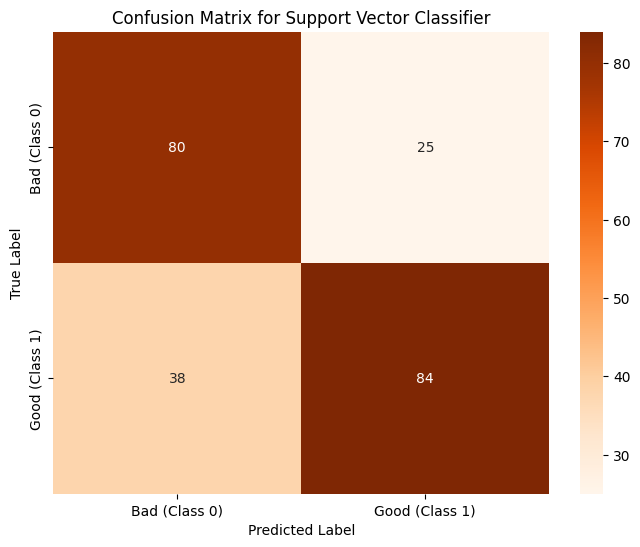

In [7]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Support Vector Classifier')
plt.show()

In [8]:
# --- 5. Hyperparameter Tuning (Finding the best parameters using GridSearchCV) ---
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001], 'kernel': ['rbf', 'linear']}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2, cv=5)
grid.fit(X_train, y_train)

print("\nBest parameters found:")
print(grid.best_params_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.


--- Model Evaluation (After Tuning) ---
Accuracy (Tuned Model): 0.7313

Classification Report (Tuned Model):
                precision    recall  f1-score   support

 Bad (Class 0)       0.72      0.68      0.70       105
Good (Class 1)       0.74      0.78      0.76       122

      accuracy                           0.73       227
     macro avg       0.73      0.73      0.73       227
  weighted avg       0.73      0.73      0.73       227



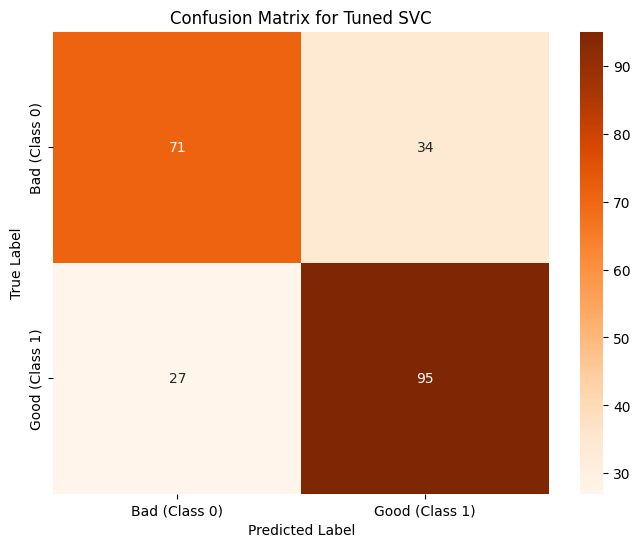

In [9]:
# --- 6. Model Evaluation After Hyperparameter Tuning ---
print("\n--- Model Evaluation (After Tuning) ---")
grid_predictions = grid.predict(X_test)

print(f"Accuracy (Tuned Model): {accuracy_score(y_test, grid_predictions):.4f}")
print("\nClassification Report (Tuned Model):")
print(classification_report(y_test, grid_predictions, target_names=target_names))

conf_matrix_tuned = confusion_matrix(y_test, grid_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_tuned, annot=True, fmt='d', cmap='Oranges',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Tuned SVC')
plt.show()

In [10]:
# --- 7. Baseline and Tuned Model Comparison ---
print("\n--- Model Comparison ---")
print(f"Baseline Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Tuned Model Accuracy: {accuracy_score(y_test, grid_predictions):.4f}")


--- Model Comparison ---
Baseline Model Accuracy: 0.7225
Tuned Model Accuracy: 0.7313


In [11]:
# --- 8. Prediction (Example) ---
# Let's take an example data point from the scaled test set
example_data_point = X_test[0].reshape(1, -1)

# Predict using the tuned model
predicted_class = grid.predict(example_data_point)

print(f"\n--- Prediction Example ---")
print(f"Example data point: {example_data_point}")
print(f"Predicted class (Tuned Model): {predicted_class[0]}")
print(f"True class: {y_test.iloc[0]}")


--- Prediction Example ---
Example data point: [[ 1.38027769 -1.57123534  1.70832259  0.17983409 -0.08819082 -1.02716186]]
Predicted class (Tuned Model): 0
True class: 1
